# Lab 01：數數也能做語言模型——n-gram、bits-per-byte 與稀疏性

對應講義：[第 01 課](../lessons/01_language_models_and_ngrams.md)

1. 下載 TinyStories，看資料長什麼樣
2. 用「數數」做 byte-level n-gram 模型，量驗證資料上的 bits-per-byte（式 1.4）
3. 看稀疏性：$n$ 越大，訓練資料越好，驗證資料卻變差——插值（式 1.8、1.9）怎麼救
4. 從 n-gram 抽樣：短前文亂、長前文拼貼訓練資料
5. 神經網路版的 bigram：梯度下降學到的就是計數（§2.5）

CPU 約 3 分鐘。

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
print(f"torch {torch.__version__}")

torch 2.14.0+cu130


## 1. 資料

TinyStories（Eldan & Li 2023）是用 GPT-3.5／GPT-4 生成、只用幼兒詞彙的短篇故事，專門拿來研究「多小的模型能說出通順英文」。
本課程只用它的 GPT-4 驗證檔（22.5 MB，CDLA-Sharing-1.0 授權），再依故事切成 90% 訓練、10% 驗證。這個切法全課程共用（`artifacts.course_stories`）。

In [2]:
from lm_course.artifacts import course_stories
from lm_course.ngram import text_to_bytes

train_stories, val_stories = course_stories()
train_text = "\n".join(train_stories)
val_text = "\n".join(val_stories)
train_bytes, val_bytes = text_to_bytes(train_text), text_to_bytes(val_text)
print(f"{len(train_stories):,} training stories, {len(val_stories):,} validation stories")
print(f"{len(train_bytes) / 1e6:.1f} MB training text, {len(val_bytes) / 1e6:.2f} MB validation text")
print(f"distinct bytes: {len(np.unique(train_bytes))}")
print()
print(val_stories[0][:400], "...")

24,867 training stories, 2,762 validation stories
19.9 MB training text, 2.22 MB validation text
distinct bytes: 89

One day, a little cricket was in the garden. He liked to jump and play. The sun was shining and the sky was blue. The cricket was happy because he had a lot of space to play.
Soon, it started to rain. The cricket did not like the rain. He looked for a place to hide. He saw a big leaf and went under it. The cricket was now safe from the rain.
After the rain, the cricket went to play again. He saw a ...


## 2. 最簡單的模型：unigram

$n=1$：完全不看前文，只用每個位元組的出現頻率。它在訓練資料上的 bits-per-byte 恰好是位元組分布的**熵**（`tests/test_ngram.py` 驗證了這一點）。
對照組：均勻分布，每個位元組 $\log_2 256 = 8$ bits。

In [3]:
from lm_course.ngram import AddKLM, bits_per_byte

values, counts = np.unique(train_bytes, return_counts=True)
freq = counts / counts.sum()
entropy = -(freq * np.log2(freq)).sum()
unigram = AddKLM(1, k=0.01).fit(train_bytes)
print(f"uniform over 256 bytes : 8.000 bits/byte")
print(f"byte entropy (train)   : {entropy:.3f} bits/byte")
print(f"unigram on validation  : {bits_per_byte(unigram, val_bytes):.3f} bits/byte")

top = np.argsort(-counts)[:12]
print("most frequent bytes:", [(chr(values[i]), round(float(freq[i]), 3)) for i in top])

uniform over 256 bytes : 8.000 bits/byte
byte entropy (train)   : 4.411 bits/byte
unigram on validation  : 4.412 bits/byte
most frequent bytes: [(' ', 0.194), ('e', 0.093), ('a', 0.069), ('t', 0.064), ('o', 0.051), ('h', 0.048), ('n', 0.046), ('d', 0.043), ('i', 0.043), ('s', 0.038), ('r', 0.034), ('l', 0.031)]


## 3. 加長前文：n-gram 與稀疏性

先一次數好 1 到 10 階的所有計數（`InterpolatedLM(10)` 裡的 10 層 `NGramCounts`），後面的模型都共用它們。
對每個 $n$ 做一個加 k 平滑（式 1.7，$k = 0.01$）的模型，同時量**訓練**與**驗證**資料的 bits-per-byte。為了公平，所有模型都從第 12 個位元組開始計分。

In [4]:
from lm_course.ngram import InterpolatedLM

MAX_N = 10
start = time.perf_counter()
ngrams = InterpolatedLM(MAX_N).fit(train_bytes)
print(f"counted orders 1..{MAX_N} in {time.perf_counter() - start:.0f}s")

orders = list(range(1, MAX_N + 1))
train_eval = train_bytes[:2_000_000]  # a slice is enough to measure training-set fit
results = []
for n in orders:
    model = AddKLM.from_counts(ngrams.levels[n - 1], k=0.01)
    results.append(
        dict(
            n=n,
            train=bits_per_byte(model, train_eval, start=12),
            val=bits_per_byte(model, val_bytes, start=12),
            contexts=model.counts.num_distinct_contexts,
        )
    )
    r = results[-1]
    print(f"n={n:2d}: train {r['train']:.3f}  val {r['val']:.3f} bits/byte, {r['contexts']:>9,} distinct contexts")

counted orders 1..10 in 20s
n= 1: train 4.412  val 4.412 bits/byte,         1 distinct contexts


n= 2: train 3.294  val 3.294 bits/byte,        89 distinct contexts


n= 3: train 2.383  val 2.391 bits/byte,     1,559 distinct contexts


n= 4: train 1.802  val 1.817 bits/byte,    11,170 distinct contexts


n= 5: train 1.506  val 1.541 bits/byte,    48,385 distinct contexts


n= 6: train 1.334  val 1.420 bits/byte,   168,727 distinct contexts


n= 7: train 1.222  val 1.405 bits/byte,   453,554 distinct contexts


n= 8: train 1.156  val 1.482 bits/byte,   919,180 distinct contexts


n= 9: train 1.115  val 1.643 bits/byte, 1,565,478 distinct contexts


n=10: train 1.100  val 1.885 bits/byte, 2,419,256 distinct contexts


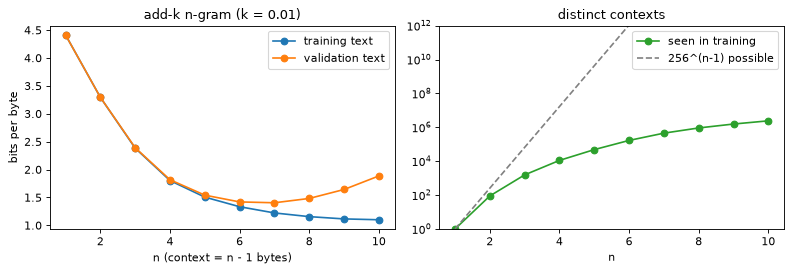

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(orders, [r["train"] for r in results], "o-", label="training text")
ax[0].plot(orders, [r["val"] for r in results], "o-", label="validation text")
ax[0].set_xlabel("n (context = n - 1 bytes)")
ax[0].set_ylabel("bits per byte")
ax[0].set_title("add-k n-gram (k = 0.01)")
ax[0].legend()
ax[1].semilogy(orders, [r["contexts"] for r in results], "o-", color="tab:green", label="seen in training")
ax[1].semilogy(orders, [256.0 ** (n - 1) for n in orders], "--", color="gray", label="256^(n-1) possible")
ax[1].set_ylim(1, 1e12)
ax[1].set_xlabel("n")
ax[1].set_title("distinct contexts")
ax[1].legend()
plt.tight_layout()
plt.show()

**讀圖**：訓練資料的 bits-per-byte 一路往下（前文越長越會「背」），驗證資料卻在 $n = 7$ 見底、之後快速回升——這就是講義 §2.4 的稀疏性，也是講義「常見誤解」說的 U 形曲線。
右圖是原因：可能的前文有 $256^{n-1}$ 種（虛線），看過的只是其中極小一部分；驗證資料裡一旦出現沒看過的前文，加 k 平滑只能退回均勻的猜測（每個位元組 8 bits）。

## 4. 插值：長前文有資料時用它，沒有時退回短前文

`InterpolatedLM` 用 Witten–Bell 插值（式 1.8、1.9）：從均勻分布開始一階一階往上疊，每一階用 $\lambda(h) = c(h) / (c(h) + u(h))$ 決定要相信這個前文多少；沒看過的前文 $\lambda = 0$，整個交給短一階的前文。`ngrams.up_to(n)` 是只用前 $n$ 階的同一個模型。

n= 1: interpolated val 4.412 bits/byte   (add-k: 4.412)


n= 2: interpolated val 3.294 bits/byte   (add-k: 3.294)


n= 3: interpolated val 2.391 bits/byte   (add-k: 2.391)


n= 4: interpolated val 1.815 bits/byte   (add-k: 1.817)


n= 5: interpolated val 1.531 bits/byte   (add-k: 1.541)


n= 6: interpolated val 1.377 bits/byte   (add-k: 1.420)


n= 7: interpolated val 1.289 bits/byte   (add-k: 1.405)


n= 8: interpolated val 1.249 bits/byte   (add-k: 1.482)


n= 9: interpolated val 1.240 bits/byte   (add-k: 1.643)


n=10: interpolated val 1.257 bits/byte   (add-k: 1.885)


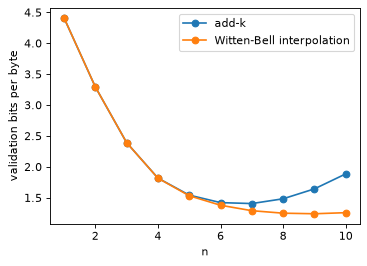

In [6]:
interp = []
for n in orders:
    interp.append(bits_per_byte(ngrams.up_to(n), val_bytes, start=12))
    print(f"n={n:2d}: interpolated val {interp[-1]:.3f} bits/byte   (add-k: {results[n - 1]['val']:.3f})")

plt.figure(figsize=(5, 3.5))
plt.plot(orders, [r["val"] for r in results], "o-", label="add-k")
plt.plot(orders, interp, "o-", label="Witten-Bell interpolation")
plt.xlabel("n")
plt.ylabel("validation bits per byte")
plt.legend()
plt.show()

插值在每個 $n$ 都不比加 k 差，最佳點往後推、也壓得更低：短前文永遠有資料可以退，長前文只在有用時才被採用。
但它也不是越長越好——過了最佳點又慢慢變差：Witten–Bell 對「只出現過一次」的長前文還是太有信心（$c = u = 1$ 時 $\lambda = 1/2$）。Kneser–Ney 等更講究的平滑會再好一些。
Lab 06 的小 GPT 會在同一份驗證資料上量 bits-per-byte，可以回來比較。

## 5. 從 n-gram 抽樣：拼貼

用**不平滑**的最大概似模型（式 1.6，$k = 0$）抽樣：它只會走訓練資料裡走過的路。同一個開頭，$n = 3, 6, 12, 20$ 各抽 250 個位元組。
（開頭必須比前文長，所以用 29 個位元組的「Once upon a time, there was a」。）

In [7]:
from lm_course.ngram import NGramCounts, sample_text

PROMPT = "Once upon a time, there was a"
start = time.perf_counter()
ml_models = {}
for n in (3, 6, 12, 20):
    level = ngrams.levels[n - 1] if n <= MAX_N else NGramCounts(n).fit(train_bytes)
    ml_models[n] = AddKLM.from_counts(level, k=0.0)
    print(f"--- n = {n} ---")
    print(sample_text(ml_models[n], PROMPT, 250, np.random.default_rng(0)))
    print()
print(f"({time.perf_counter() - start:.0f}s)")

--- n = 3 ---
Once upon a time, there was and Don. Sue une up id som wound and low, The was to the jum in scamild thip. Yourgird. They, try wited the was an thigh hey day a more histappy ho the gard. Eved love. They countoll box jump, bat It's and puld al saings. Ells. He sher mands wittlet t

--- n = 6 ---
Once upon a time, there was a faces. Sue was very day.
While Spot wing. It is too.
Now, I can play with his house, there.
Tom were twins.
Once upon a tree was play together crayon and star. It's go."
When toys. He get smelly anymore. Tim was sad. The barn, there is sounds on the



--- n = 12 ---
Once upon a time, there was a fairy! She was so happy! When they got tired. They said they couldn't wait to play too.
Tom whistled in the stadium.
Once upon a time, there was a little girl named Lucy went to the park. She heard a loud voice.
Lily was a very good at sorting.
Afte



--- n = 20 ---
Once upon a time, there was a factory. In the factory, they made pretty toys. Many people came to listen to Sue and the bird. They went to the store together, holding on to the handle and you'll be safe."
Feeling much calmer, Amy held the handle tight and the old man took her ho

(13s)


$n = 3$ 連單字都拼不好；$n = 12$、$20$ 時單字與句子都很通順，但故事東跳西跳。
它是在「創作」還是在「剪貼」？把生成的文字切成長度 10、20、40 個字元的片段，檢查有多少原封不動出現在訓練資料裡：

In [8]:
def verbatim_fraction(text: str, corpus: str, width: int) -> float:
    windows = [text[i : i + width] for i in range(len(PROMPT), len(text) - width, 3)]
    return float(np.mean([w in corpus for w in windows]))


widths = (10, 20, 40)
print(f"{'':>6}" + "".join(f"{f'{w} chars':>10}" for w in widths))
for n, model in ml_models.items():
    samples = [sample_text(model, PROMPT, 300, np.random.default_rng(s)) for s in range(5)]
    row = [np.mean([verbatim_fraction(s, train_text, w) for s in samples]) for w in widths]
    print(f"n = {n:<2}" + "".join(f"{v:>10.0%}" for v in row))

        10 chars  20 chars  40 chars


n = 3         8%        0%        0%


n = 6        70%        6%        0%


n = 12      100%       39%        3%


n = 20      100%      100%       34%


不平滑的 $n$-gram 每一步都接在一段看過的 $n-1$ 個字元後面，所以**任何 $n$ 個字元以內的片段都一定來自訓練資料**；$n = 20$ 時，連 40 個字元的片段也有相當比例是原封不動的。
生成的是**拼貼**：局部通順，因為每一小段都是真人（在這裡是 GPT-4）寫的；整體不連貫，因為拼接處只看得到前 $n - 1$ 個字元。
**低 loss 不等於會創造**——神經網路要做的，是在相似（而不是完全相同）的前文之間分享統計。

## 6. 神經網路版的 bigram

一張 $256 \times 256$ 的可學表格 $W$，$p(x_t = j \mid x_{t-1} = i) = \mathrm{softmax}(W_{i,:})_j$，用 Adam 最小化交叉熵（式 1.2）。
講義 §2.5 說它的最佳解就是計數比例；這裡直接比較兩者。

In [9]:
import torch.nn.functional as F

x = torch.from_numpy(train_bytes[:-1].astype(np.int64))
y = torch.from_numpy(train_bytes[1:].astype(np.int64))
W = torch.zeros(256, 256, requires_grad=True)
opt = torch.optim.Adam([W], lr=0.1)
g = torch.Generator().manual_seed(0)
losses = []
for step in range(1500):
    idx = torch.randint(0, len(x), (8192,), generator=g)
    loss = F.cross_entropy(W[x[idx]], y[idx])
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

counted = AddKLM.from_counts(ngrams.levels[1], k=0.0)
xv = torch.from_numpy(val_bytes[:-1].astype(np.int64))
yv = torch.from_numpy(val_bytes[1:].astype(np.int64))
with torch.no_grad():
    neural_bpb = F.cross_entropy(W[xv], yv).item() / np.log(2)
print(f"neural bigram, validation : {neural_bpb:.3f} bits/byte")
print(f"counted bigram (add-k 0.01): {results[1]['val']:.3f} bits/byte")

# compare the learned distribution after "t" with the counts
row = ord("t")
learned = torch.softmax(W[row], dim=0).detach().numpy()
empirical = counted.next_distribution(b"t")
top = np.argsort(-empirical)[:8]
print("after 't':", ", ".join(f"{chr(j)!r} {empirical[j]:.3f}/{learned[j]:.3f}" for j in top), "(counted/learned)")

neural bigram, validation : 3.300 bits/byte
counted bigram (add-k 0.01): 3.294 bits/byte
after 't': 'h' 0.312/0.310, ' ' 0.238/0.230, 'o' 0.164/0.162, 'e' 0.064/0.073, 'i' 0.036/0.033, 't' 0.030/0.025, '.' 0.027/0.026, 'r' 0.026/0.029 (counted/learned)


兩者幾乎一樣：**梯度下降學到的就是計數**。神經網路的價值不在表格模型，而在於能換成別的函數形式——
把「前一個字」換成「前面所有字」、把「查表」換成「相似的前文得到相似的表示」。這條路從第 02 課的詞向量開始。

## 小結

In [10]:
best = min(results, key=lambda r: r["val"])
best_interp = int(np.argmin(interp))
print(f"{'model':<34}validation bits/byte")
print(f"{'uniform':<34}{8.0:.3f}")
print(f"{'unigram':<34}{results[0]['val']:.3f}")
print(f"{'best add-k (n = ' + str(best['n']) + ')':<34}{best['val']:.3f}")
print(f"{'best Witten-Bell (n = ' + str(orders[best_interp]) + ')':<34}{interp[best_interp]:.3f}")
print(f"{'neural bigram':<34}{neural_bpb:.3f}")

model                             validation bits/byte
uniform                           8.000
unigram                           4.412
best add-k (n = 7)                1.405
best Witten-Bell (n = 9)          1.240
neural bigram                     3.300


下一步：[第 02 課](../lessons/02_word2vec.md)——讓相似的詞有相似的向量。